In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
#from numpy.core.multiarray import ndarray
from sklearn.preprocessing import StandardScaler
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial import distance_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.cluster import contingency_matrix
from collections.abc import ValuesView
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_moons
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.cluster import KElbowVisualizer 
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pandas import set_option
from random import sample
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn import metrics
from IPython.display import Image
#from pydotplus import graph_from_dot_data
from sklearn.model_selection import train_test_split
from __future__ import print_function
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from sklearn.cluster import KMeans

In [2]:
df_original = pd.read_excel("phyllis.xlsm", engine='openpyxl')

In [3]:
df_original.describe()

,SampleNo,Bulkdensity(ar),AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,...,CaO,MgO,Na2O,K2O,Cl,Pb,Cd,Cu,Cr,Hg
count,3000.000000,133.000000,1340.000000,958.000000,889.000000,889.000000,1148.000000,1140.000000,1171.000000,1001.000000,...,531.000000,527.000000,507.000000,528.000000,190.000000,147.000000,144.000000,163.000000,51.000000,96.000000
mean,1823.759000,392.022556,18.596254,8.074353,59.897019,17.194668,40.971429,4.889377,1.095021,0.297313,...,17.212712,3.933814,1.820907,14.068580,2.782895,2145.634694,20.238889,930.342331,14371.996078,0.048958
std,1055.716969,301.498718,21.410005,11.722135,20.192523,13.087025,14.876643,2.509693,1.804127,0.718854,...,13.699322,3.461826,3.334405,11.912665,3.331602,9260.325085,88.280062,7112.980767,61635.566005,0.256287
min,1.000000,1.000000,0.000000,0.000000,0.100000,-1.350000,0.860000,0.110000,0.000000,0.000000,...,0.150000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,929.750000,139.000000,5.700000,1.302500,48.310000,10.800000,33.197500,3.967500,0.230000,0.040000,...,6.900000,2.000000,0.310000,3.755000,0.222500,3.500000,0.000000,40.000000,60.500000,0.000000
50%,1827.500000,273.000000,9.480000,3.250000,66.900000,14.790000,42.420000,5.100000,0.520000,0.090000,...,12.380000,3.000000,0.800000,11.250000,1.795000,15.000000,0.100000,83.000000,180.000000,0.000000
75%,2709.250000,612.000000,22.000000,8.892500,74.000000,18.300000,46.980000,5.590000,1.190000,0.260000,...,25.075000,4.755000,1.885000,21.725000,3.835000,52.100000,0.800000,261.500000,565.000000,0.000000
max,3599.000000,1211.000000,95.700000,82.040000,100.000000,88.260000,89.380000,56.540000,21.560000,11.640000,...,66.000000,45.880000,29.900000,52.900000,19.200000,63000.000000,630.000000,89300.000000,382500.000000,1.800000


In [4]:
df_prediction = df_original[['Material', 'AR_Moisturecontent', 'AR_Ashcontent', 'AR_Volatilematter', 'AR_Fixedcarbon', 'AR_Netcalorificvalue(LHV)', 'AR_Carbon', 'AR_Hydrogen', 'AR_Nitrogen', 'AR_Sulphur', 'AR_Oxygen']]

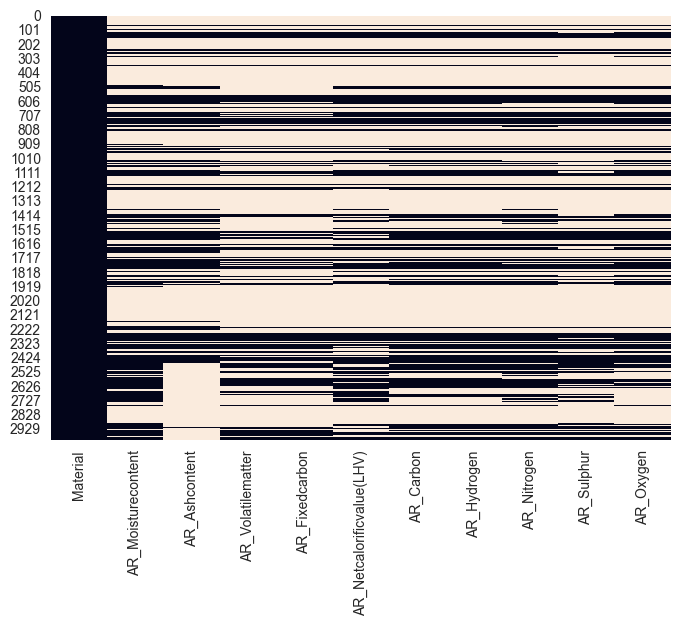

In [5]:
sns.heatmap(df_prediction.isnull(), cbar=False)
plt.show()

In [6]:
df_prediction = df_prediction.copy()
df_prediction.replace(0, np.nan, inplace=True)
df_clean_pre = df_prediction.dropna()
print(df_clean_pre.isnull().sum())
print(df_clean_pre.shape)

Material                     0
AR_Moisturecontent           0
AR_Ashcontent                0
AR_Volatilematter            0
AR_Fixedcarbon               0
AR_Netcalorificvalue(LHV)    0
AR_Carbon                    0
AR_Hydrogen                  0
AR_Nitrogen                  0
AR_Sulphur                   0
AR_Oxygen                    0
dtype: int64
(498, 11)


In [7]:
df_clean_pre.describe()

,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen
count,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000,498.000000
mean,15.579056,9.386345,58.495120,16.382269,14.890723,40.331205,4.677972,0.974498,0.304659,28.760622
std,18.184536,12.720269,19.565428,12.672272,5.699371,13.599430,1.452957,1.447722,0.652552,11.386553
min,0.100000,0.060000,3.820000,-1.350000,-1.220000,2.360000,0.260000,0.020000,0.010000,0.390000
25%,5.905000,1.465000,45.597500,10.395000,12.322500,33.860000,4.030000,0.240000,0.040000,20.662500
50%,9.400000,4.400000,65.640000,14.105000,15.400000,42.195000,5.065000,0.520000,0.090000,32.555000
75%,14.365000,10.970000,73.077500,17.040000,17.197500,46.582500,5.510000,1.082500,0.280000,38.047500
max,93.040000,77.690000,89.900000,87.700000,37.850000,87.250000,11.700000,11.730000,8.870000,48.300000


In [8]:
column_name=['AR_Moisturecontent','AR_Ashcontent','AR_Volatilematter','AR_Fixedcarbon','AR_Netcalorificvalue(LHV)','AR_Sulphur', 'AR_Nitrogen','AR_Carbon','AR_Hydrogen','AR_Oxygen']
def plot_hist_hq(df, column, bins, scale, fontsize_base=16):

    data = df[column].dropna()

    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(14, 10),
        gridspec_kw={'height_ratios': [6, 1], 'hspace': 0.03},
        sharex=True,
    )

    bp = ax_box.boxplot(
        data, vert=False, patch_artist=True,
        widths=0.5,
        boxprops    =dict(facecolor='#FF8C42', color='#B85C00', linewidth=2.0),
        medianprops =dict(color='#B85C00', linewidth=2.0),
        whiskerprops=dict(color='#B85C00', linewidth=2.0),
        capprops    =dict(color='#B85C00', linewidth=2.0),
        flierprops  =dict(marker='o', color='#B85C00',
                          markerfacecolor='white', markeredgecolor='#B85C00',
                          markersize=6, linestyle='none', linewidth=1.5),
    )
    ax_box.set_yticks([])
    ax_box.spines['left'].set_visible(False)
    ax_box.spines['right'].set_visible(False)
    ax_box.tick_params(axis='x', labelsize=fontsize_base)

    counts, edges, _ = ax_hist.hist(
        data, bins=bins,
        color='#5DAE4A', edgecolor='white',
        linewidth=1.2,
    )

    for count, left, right in zip(counts, edges[:-1], edges[1:]):
        if count > 0:
            ax_hist.text(
                (left + right) / 2, count + 1.5,
                str(int(count)),
                ha='center', va='bottom',
                fontsize=fontsize_base + 4,
                fontweight='bold',
                color='#000000',
            )

    average = data.mean()
    median = data.median()

    ax_hist.axvline(average, color='#E85D04', linewidth=2.5,
                    linestyle='--', label='Average')
    ax_hist.axvline(median, color='#2D6A4F', linewidth=2.5,
                    linestyle='-', label='Median')

    ax_hist.set_yscale(scale)
    ax_hist.set_ylabel('Absolute Frequency', fontsize=fontsize_base + 3, labelpad=12)
    ax_box.set_xlabel(column, fontsize=fontsize_base + 3, labelpad=12)

    fig.suptitle(f'Histogram and Boxplot of {column}',
                 fontsize=fontsize_base + 6, fontweight='normal', y=0.98)

    ax_hist.grid(axis='y', linestyle='-', linewidth=0.8,
                 color='#DDDDDD', alpha=0.9)
    ax_hist.set_axisbelow(True)

    ax_hist.legend(
        frameon=True, framealpha=1.0,
        edgecolor='#AAAAAA',
        fontsize=fontsize_base + 1,
        loc='upper right',
    )

    ax_hist.tick_params(axis='both', which='major',
                        labelsize=fontsize_base, width=1.5, length=6)
    ax_hist.tick_params(axis='both', which='minor',
                        width=1.0, length=3)
    ax_hist.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))

    for ax in [ax_hist, ax_box]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    return fig, (ax_box, ax_hist)

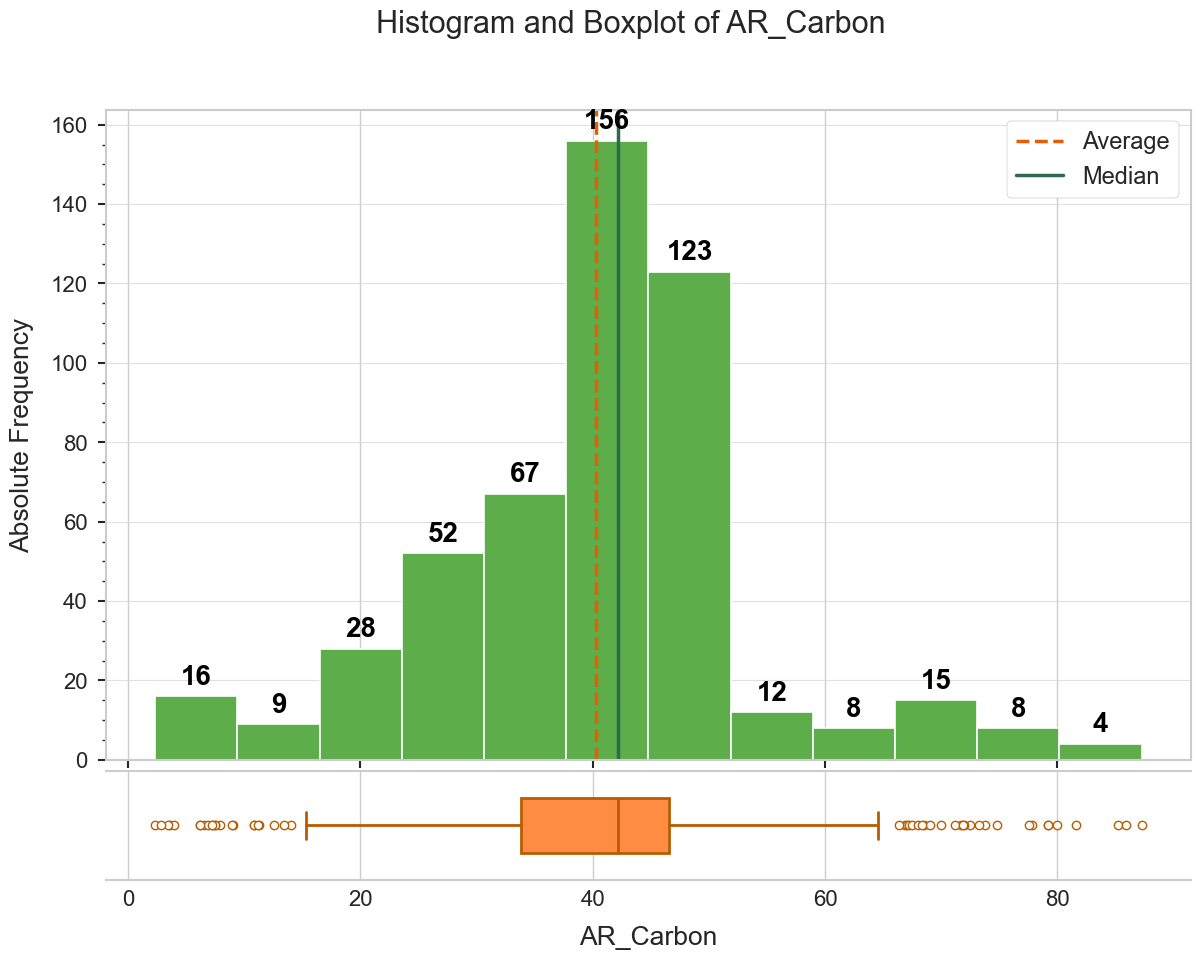

In [ ]:
fig, axs = plot_hist_hq(df_clean_pre, 'AR_Carbon', 12, 'linear')  
fig.savefig('histograma_boxplot_GR.png', format='png', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

In [10]:
clf = LocalOutlierFactor(n_neighbors=50, contamination='auto', metric='minkowski', n_jobs=-1)
y_pred = clf.fit_predict(df_clean_pre[column_name])
X_scores = clf.negative_outlier_factor_
n_inliers = (y_pred == 1).sum(); print(f"Number of inliers: {n_inliers}")
n_outliers = (y_pred == -1).sum(); print(f"Number of outliers: {n_outliers}")
print(f"Outliers detected: {n_outliers} ({n_outliers / n_inliers * 100:.2f}%)")
n_total = n_inliers + n_outliers; print(f"Total: {n_total}")

df_inliers = df_clean_pre[y_pred == 1]
print("Shape df_inliers:", df_inliers.shape)

Number of inliers: 439
Number of outliers: 59
Outliers detected: 59 (13.44%)
Total: 498
Shape df_inliers: (439, 11)


In [11]:
df_inliers[column_name].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
AR_Moisturecontent,439.0,15.519476,16.970635,0.10,6.200,9.70,14.700,83.70
AR_Ashcontent,439.0,9.466515,12.630175,0.06,1.365,4.38,11.225,64.11
AR_Volatilematter,439.0,58.433075,18.685827,4.82,45.420,65.30,72.425,85.78
AR_Fixedcarbon,439.0,16.516287,12.644028,0.60,11.130,14.19,16.915,87.70
AR_Netcalorificvalue(LHV),439.0,14.690888,5.295366,0.19,12.025,15.32,16.865,36.10
AR_Sulphur,439.0,0.298542,0.670627,0.01,0.040,0.09,0.270,8.87
AR_Nitrogen,439.0,0.916469,1.172867,0.02,0.230,0.53,1.095,9.20
AR_Carbon,439.0,40.047699,12.904476,6.20,33.230,42.09,46.355,87.25
AR_Hydrogen,439.0,4.626264,1.304592,0.75,3.985,5.02,5.465,8.32
AR_Oxygen,439.0,29.114692,10.853259,0.39,21.245,33.62,38.015,43.41


In [12]:
df_filtrados = df_inliers [df_inliers ['AR_Nitrogen'] <= 5.5]
df_filtrados = df_filtrados [df_filtrados ['AR_Sulphur'] <= 2]
print(df_filtrados)

        Material  AR_Moisturecontent  AR_Ashcontent  AR_Volatilematter  \
50          bark               12.30           3.50              70.36   
65          wood               10.00           0.32              75.59   
67          wood                8.12           0.40              76.84   
68          wood               12.37           0.55              73.98   
70          wood               10.00           0.78              76.03   
...          ...                 ...            ...                ...   
2438      Litchi               59.86           0.96              27.50   
2439      Longan               35.06           2.16              45.30   
2440  bituminous                3.00           9.30              33.20   
2441        wood               12.40           0.90              71.70   
2751         MSW               25.62          29.54              39.86   

      AR_Fixedcarbon  AR_Netcalorificvalue(LHV)  AR_Carbon  AR_Hydrogen  \
50             13.84                

In [16]:
df_filtrados.to_csv('df_datosMLp2R.csv', index=False)

In [17]:
df_limpiototal = pd.read_csv('df_datosMLp2R.csv')
material = df_limpiototal['Material']
da1 = df_limpiototal.drop(columns=['Material']).to_numpy()

In [18]:
print(da1.shape) 

(426, 10)


In [19]:
scaler = MinMaxScaler();
scaler.fit(da1);
da1=scaler.fit_transform(da1);
da2 = da1
print(da1)

[[0.14593301 0.05370804 0.80953557 ... 0.01465201 0.02525253 0.79618734]
 [0.11842105 0.00405933 0.87413538 ... 0.01282051 0.03535354 0.89879972]
 [0.09593301 0.00530835 0.8895751  ... 0.02014652 0.01010101 0.89762297]
 ...
 [0.034689   0.1442623  0.35054348 ... 0.22161172 0.17171717 0.20334196]
 [0.14712919 0.01311475 0.82608696 ... 0.01282051 0.         0.80277712]
 [0.30526316 0.46026542 0.43280632 ... 0.24542125 0.25252525 0.33349023]]


In [20]:
df4=pd.DataFrame(data=da2)

In [21]:
df5 = df4[[0, 1, 2, 3,4]]
df51 = df4[[5, 6, 7, 8,9]]

In [22]:
df5.describe()

,0,1,2,3,4
count,426.000000,426.000000,426.000000,426.000000,426.000000
mean,0.188208,0.140697,0.667208,0.178949,0.421152
std,0.204793,0.195201,0.229602,0.136657,0.151220
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074282,0.020180,0.509542,0.121383,0.346486
50%,0.115909,0.063232,0.752903,0.156372,0.443045
75%,0.178230,0.146097,0.838439,0.186223,0.486310
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
# Agglomerative Clustering
agglom = AgglomerativeClustering()
agglom.fit(df5)

AgglomerativeClustering()

In [24]:
# Distance Matrix Configuration
distance_threshold = 100
compute_full_tree = True
agglom = AgglomerativeClustering(n_clusters=None, distance_threshold=distance_threshold, linkage='average')

In [25]:
# Print Distance Matrix
dist_matrix = distance_matrix(df5, df5)
print(dist_matrix)

[[0.         0.08743076 0.11139491 ... 0.76231212 0.05376623 0.61613526]
 [0.08743076 0.         0.0329244  ... 0.79810865 0.0590128  0.70114577]
 [0.11139491 0.0329244  0.         ... 0.79513226 0.08216913 0.72253418]
 ...
 [0.76231212 0.79810865 0.79513226 ... 0.         0.75760157 0.90048002]
 [0.05376623 0.0590128  0.08216913 ... 0.75760157 0.         0.66414352]
 [0.61613526 0.70114577 0.72253418 ... 0.90048002 0.66414352 0.        ]]


In [26]:
# K-Means Configuration
loops = 20
max_iterations = 200
initialize_clusters = 'k-means++'
convergence_tolerance = 0.01

In [27]:
# Cluster Inertia Calculation
inertia_clusters=list()
for i in range (1, loops+ 1,1):
  #object KMeans
  kmeans=KMeans(n_clusters=i, max_iter=max_iterations,
                init=initialize_clusters, tol=convergence_tolerance, n_init=100)
  #Calculate Kmeans
  kmeans.fit(df5)
  #Obtain inertia
  inertia_clusters.append([i, kmeans.inertia_])

In [28]:
# Plot Cluster Inertia Results
def plot_results(inertials):
    x, y = zip(*[inertia for inertia in inertials])
    plt.plot(x, y, 'r*-', markersize=8, lw=2)
    plt.grid(True)
    plt.xlabel('Num Clusters', fontsize=12)
    plt.ylabel('Inertia', fontsize=12)
    plt.show()

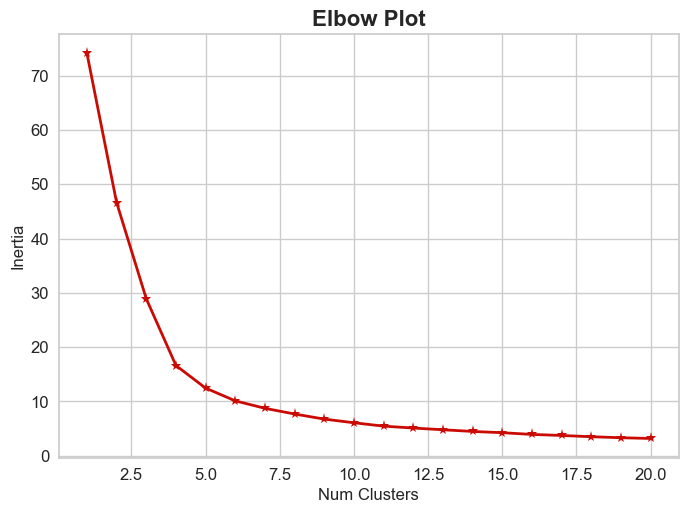

In [29]:
# Plot Elbow Curve
plt.title('Elbow Plot', fontsize=16, fontweight='bold')
#fig.savefig('elbow_plot.png')
plt.tick_params(axis='both', labelsize=12)

plt.xlabel('Number of Clusters', fontsize=14)
plt.ylabel('Inertia', fontsize=14)
plot_results(inertia_clusters)

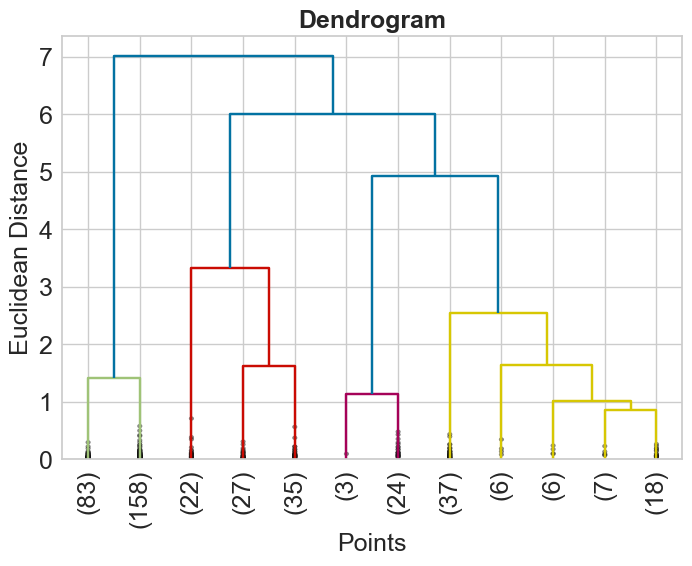

In [30]:
# Plot Dendrogram
def plot_dendrogram(dataset):
    Z = linkage(dataset, metric='euclidean', method='ward')
    plt.tick_params(axis='both', labelsize=18)
    plt.title('Dendrogram', fontsize=18, fontweight='bold')
    plt.xlabel('Points', fontsize=18)
    plt.ylabel('Euclidean Distance', fontsize=18)
    fig.savefig('dendrogram1.png')
    dendrogram(
        Z,
        truncate_mode='lastp',
        p=12,
        leaf_rotation=90.,
        leaf_font_size=18.,
        show_contracted=True
    )
    plt.show()
plot_dendrogram(df5)

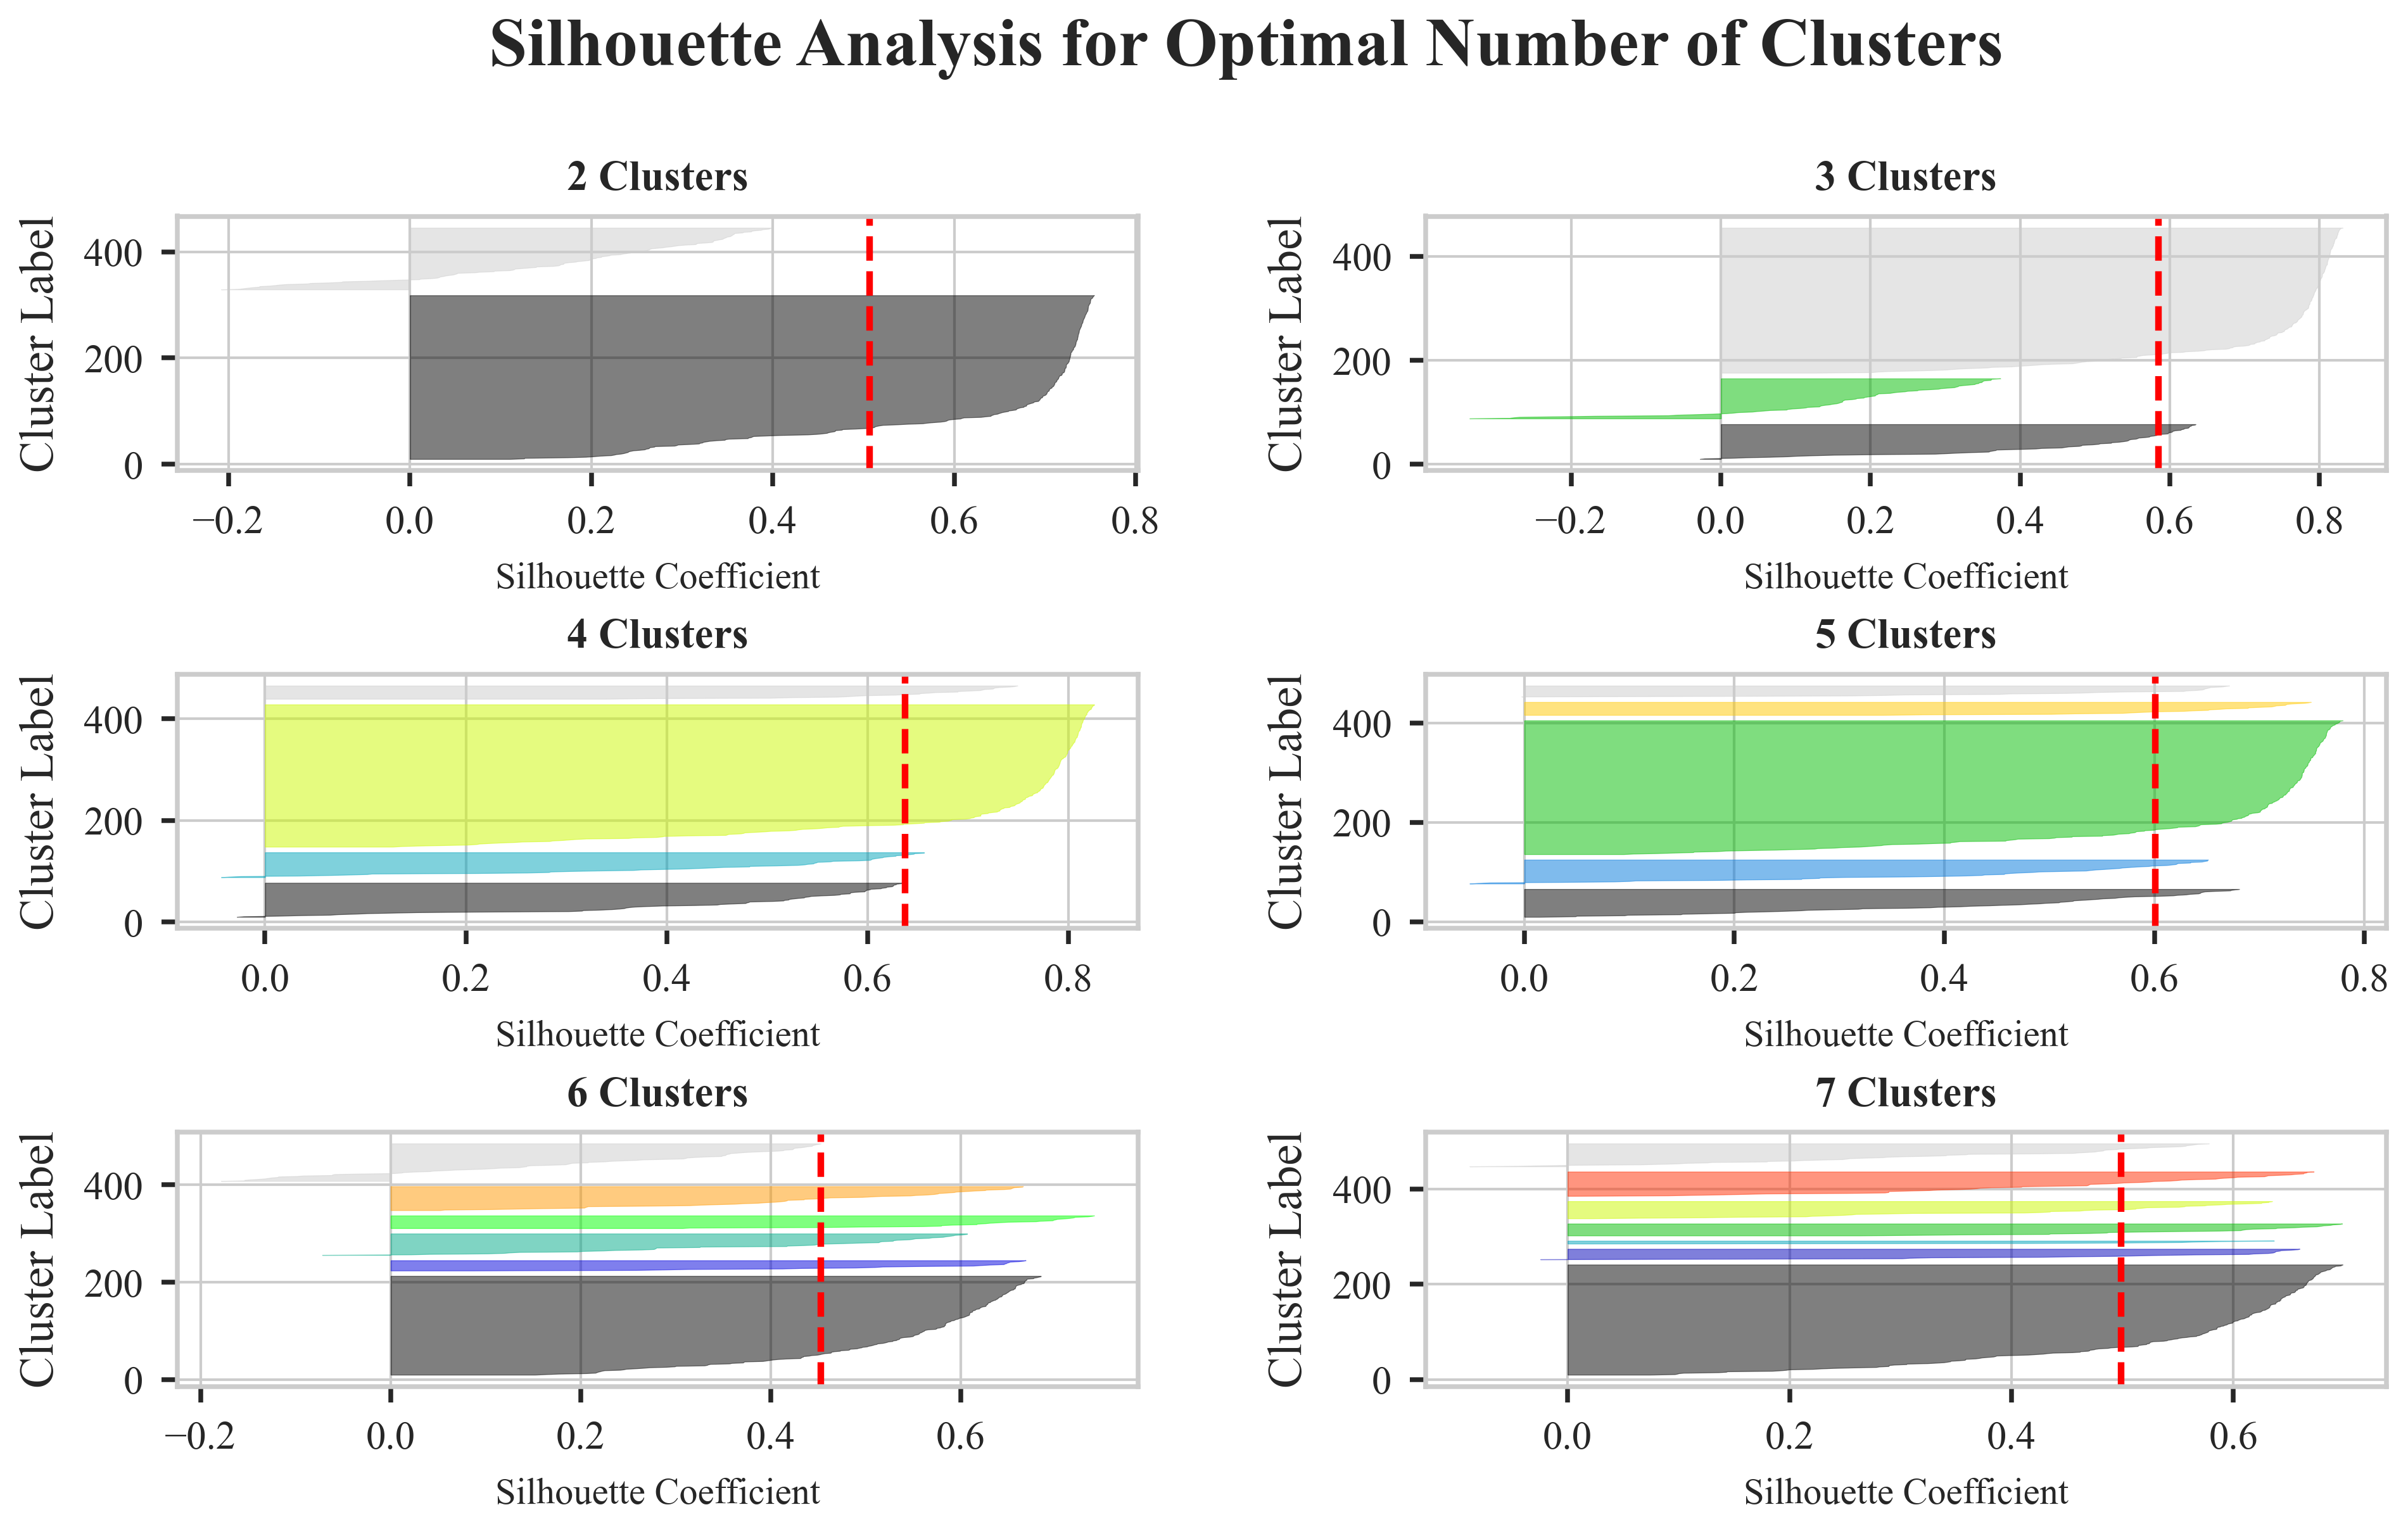

In [31]:
# Silhouette Analysis for Optimal Number of Clusters

X = df5.values
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':         16,
    'axes.titlesize':    20,
    'axes.labelsize':    18,
    'xtick.labelsize':   15,
    'ytick.labelsize':   15,
    'axes.linewidth':    1.8,
    'xtick.major.width': 1.8,
    'ytick.major.width': 1.8,
    'xtick.major.size':  7,
    'ytick.major.size':  7,
    'lines.linewidth':   2.0,
    'figure.dpi':        300,
})

fig, ax = plt.subplots(
    3, 2,
    figsize=(15, 8),
    gridspec_kw={'hspace': 0.8, 'wspace': 0.3},
)
ax = ax.flatten()

for i, n_clusters in enumerate(range(2, 8)):
    km = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=10,
        max_iter=100,
        random_state=42,
    )
    visualizer = SilhouetteVisualizer(km, colors='nipy_spectral', ax=ax[i])
    visualizer.fit(X)

    ax[i].set_title(f'{n_clusters} Clusters', fontsize=16, fontweight='bold', pad=10)
    ax[i].set_xlabel('Silhouette Coefficient', fontsize=14, labelpad=8)
    ax[i].set_ylabel('Cluster Label', fontsize=18, labelpad=8)

    ax[i].tick_params(axis='both', which='major', labelsize=15, width=1.8, length=6)
    ax[i].tick_params(axis='both', which='minor', width=1.0, length=3)

    for spine in ax[i].spines.values():
        spine.set_linewidth(1.8)

    for line in ax[i].get_lines():
        line.set_linewidth(2.5)

fig.suptitle('Silhouette Analysis for Optimal Number of Clusters',
             fontsize=26, fontweight='bold', y=1.01)

fig.savefig(
    'silhouette_analysis.png',
    format='png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
)

plt.show()

Shape after PCA: (426, 5)

Explained variance per component:
[8.82003072e-02 5.10941346e-02 3.39259192e-02 1.00317700e-03
 7.97839046e-05]

Explained variance ratio:
[5.06016215e-01 2.93133453e-01 1.94637250e-01 5.75535214e-03
 4.57730259e-04]

Cumulative variance:
[0.50601621 0.79914967 0.99378692 0.99954227 1.        ]

Total variance captured: 100.00%


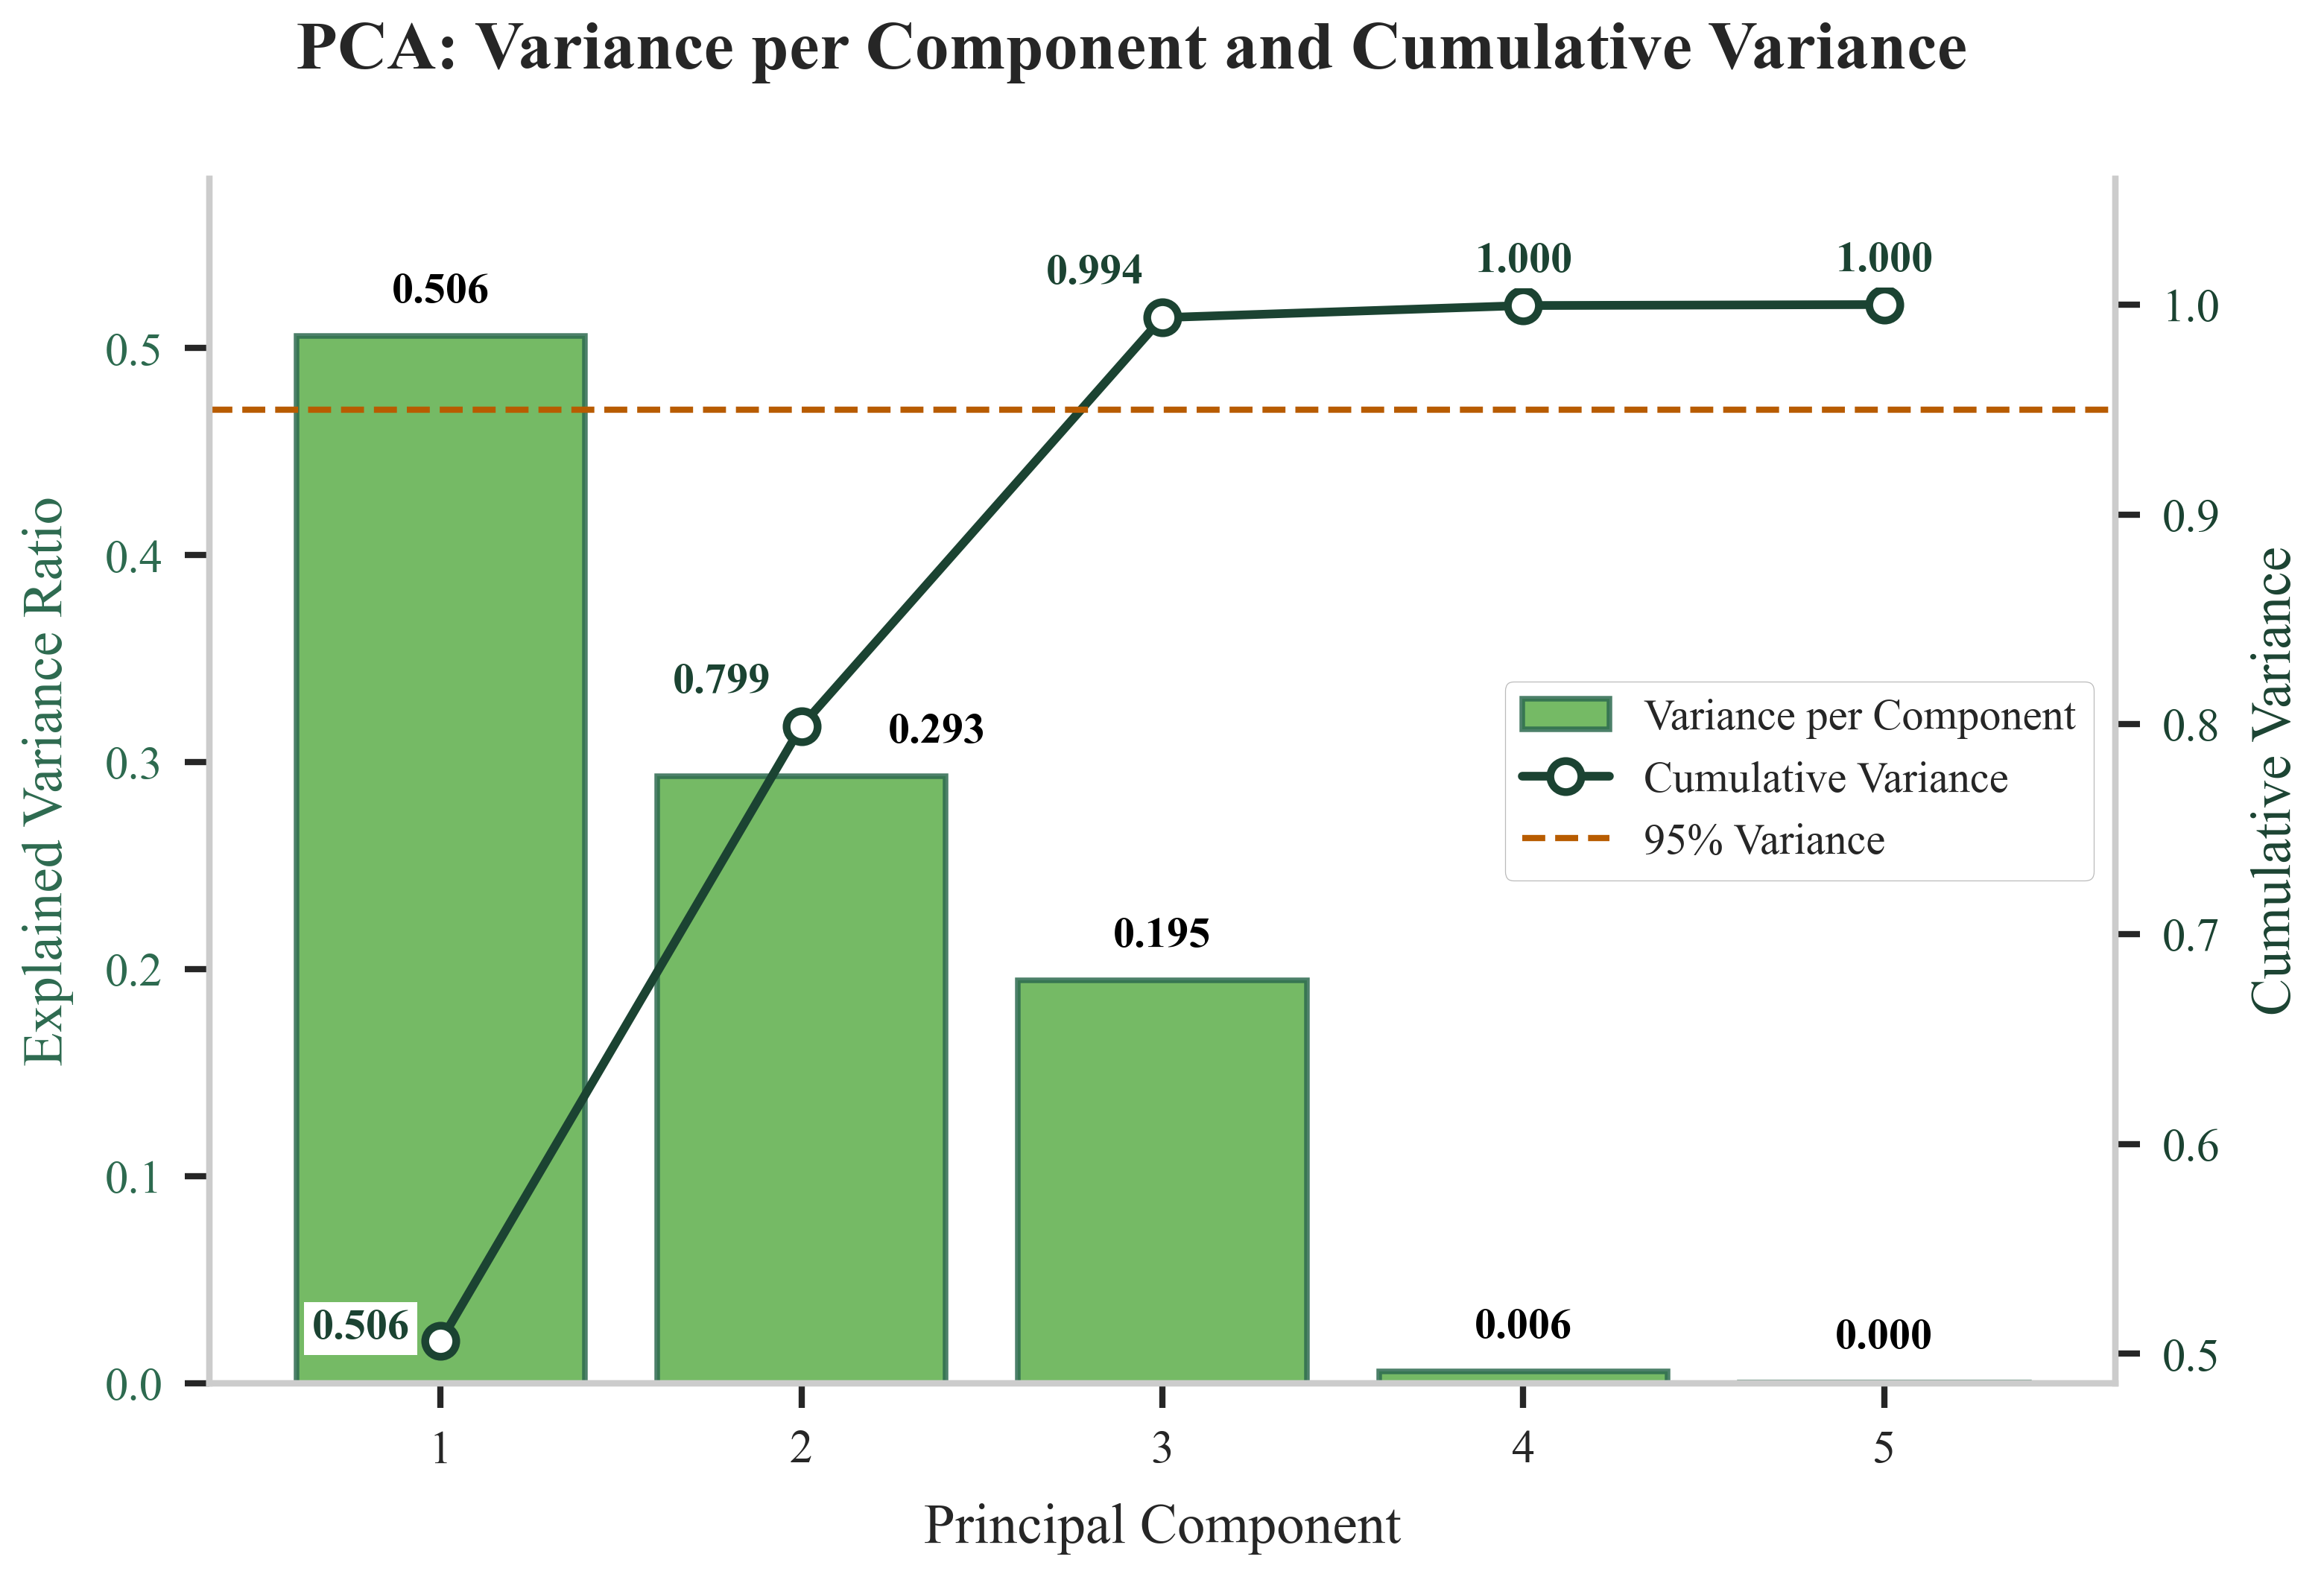

In [32]:
# PCA: Explained Variance and Cumulative Variance
n_components = 5
pca_model = PCA(n_components=n_components)
X_pca = pca_model.fit_transform(X)
print(f"Shape after PCA: {X_pca.shape}")
print(f"\nExplained variance per component:\n{pca_model.explained_variance_}")
print(f"\nExplained variance ratio:\n{pca_model.explained_variance_ratio_}")
print(f"\nCumulative variance:\n{np.cumsum(pca_model.explained_variance_ratio_)}")
print(f"\nTotal variance captured: {np.sum(pca_model.explained_variance_ratio_)*100:.2f}%")

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 16,
    'axes.titlesize': 20, 'axes.labelsize': 18,
    'xtick.labelsize': 15, 'ytick.labelsize': 15,
    'axes.linewidth': 2.0, 'xtick.major.width': 2.0,
    'ytick.major.width': 2.0, 'xtick.major.size': 8,
    'ytick.major.size': 8,
})

var_ratio = pca_model.explained_variance_ratio_
cumvar = np.cumsum(var_ratio)

fig, ax1 = plt.subplots(figsize=(11, 7))

ax1.bar(range(1, n_components + 1), var_ratio,
        color='#5DAE4A', alpha=0.85, edgecolor='#2D6A4F', linewidth=1.8,
        label='Variance per Component')
bar_labels = {
    1: dict(xytext=(0, 8),    ha='center'),
    2: dict(xytext=(28, 8),   ha='left'),
    3: dict(xytext=(0, 8),    ha='center'),
    4: dict(xytext=(0, 8),    ha='center'),
    5: dict(xytext=(0, 8),    ha='center'),
}
for x, val in enumerate(var_ratio, start=1):
    cfg = bar_labels[x]
    ax1.annotate(f'{val:.3f}', xy=(x, val), textcoords='offset points',
                 va='bottom', fontsize=14, fontweight='bold', color='black',
                 **cfg)

ax1.set_xlabel('Principal Component', fontsize=18, labelpad=10)
ax1.set_ylabel('Explained Variance Ratio', fontsize=18, labelpad=10, color='#2D6A4F')
ax1.set_xticks(range(1, n_components + 1))
ax1.tick_params(axis='y', labelcolor='#2D6A4F')
ax1.grid(False)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.set_ylim(0, max(var_ratio) * 1.15)

ax2 = ax1.twinx()
ax2.plot(range(1, n_components + 1), cumvar, 'o-', color='#1B4332',
         linewidth=2.8, markersize=10, markerfacecolor='white',
         markeredgewidth=2.5, markeredgecolor='#1B4332',
         label='Cumulative Variance')
ax2.axhline(y=0.95, color='#B85C00', linestyle='--', linewidth=2.0, label='95% Variance')
line_labels = {
    1: dict(xytext=(-10, 4),  ha='right',  va='center'),
    2: dict(xytext=(-10, 8),  ha='right',  va='bottom'),
    3: dict(xytext=(-6, 8),   ha='right',  va='bottom'),
    4: dict(xytext=(0, 8),    ha='center', va='bottom'),
    5: dict(xytext=(0, 8),    ha='center', va='bottom'),
}
for x, val in enumerate(cumvar, start=1):
    cfg = line_labels[x]
    ax2.annotate(f'{val:.3f}', xy=(x, val), textcoords='offset points',
                 fontsize=14, fontweight='bold', color='#1B4332', zorder=10,
                 bbox=dict(facecolor='white', edgecolor='none', alpha=1.0, pad=2.5),
                 **cfg)

ax2.set_ylabel('Cumulative Variance', fontsize=18, labelpad=10, color='#1B4332')
ax2.tick_params(axis='y', labelcolor='#1B4332')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.set_ylim(min(cumvar) - 0.02, max(cumvar) * 1.06)

fig.suptitle('PCA: Variance per Component and Cumulative Variance',
             fontsize=22, fontweight='bold', y=0.98)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=14,
           frameon=True, edgecolor='#AAAAAA', loc='center right')

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

fig.savefig('pca_variance.png', format='png', bbox_inches='tight', facecolor='white')
plt.show()

In [33]:
pca = PCA(n_components=2,svd_solver='full', random_state=42)
da_pca = pca.fit_transform(X)
da_pca[:,0]*=-1
df_pca = pd.DataFrame(data = da_pca, columns = ['C1', 'C2'])

In [34]:
# K-Means Clustering on PCA Components
clustering = KMeans(algorithm = "elkan", copy_x = True, init = 'k-means++', max_iter = 40000,
       n_clusters =4, n_init = 100)
kmeans6 = clustering.fit(df_pca)
centroides = kmeans6.cluster_centers_
print(centroides)
nombres_pca = pd.concat([df_pca, pd.DataFrame(data = clustering.labels_, columns = ['cluster'])], axis = 1)
nombres_pca
conteo_cluester1 = nombres_pca.groupby('cluster').size()
print(conteo_cluester1)

[[ 0.1771218  -0.05555601]
 [-0.82072663 -0.30176298]
 [-0.15357226  0.42045773]
 [-0.30048716 -0.16540792]]
cluster
0    270
1     23
2     75
3     58
dtype: int64


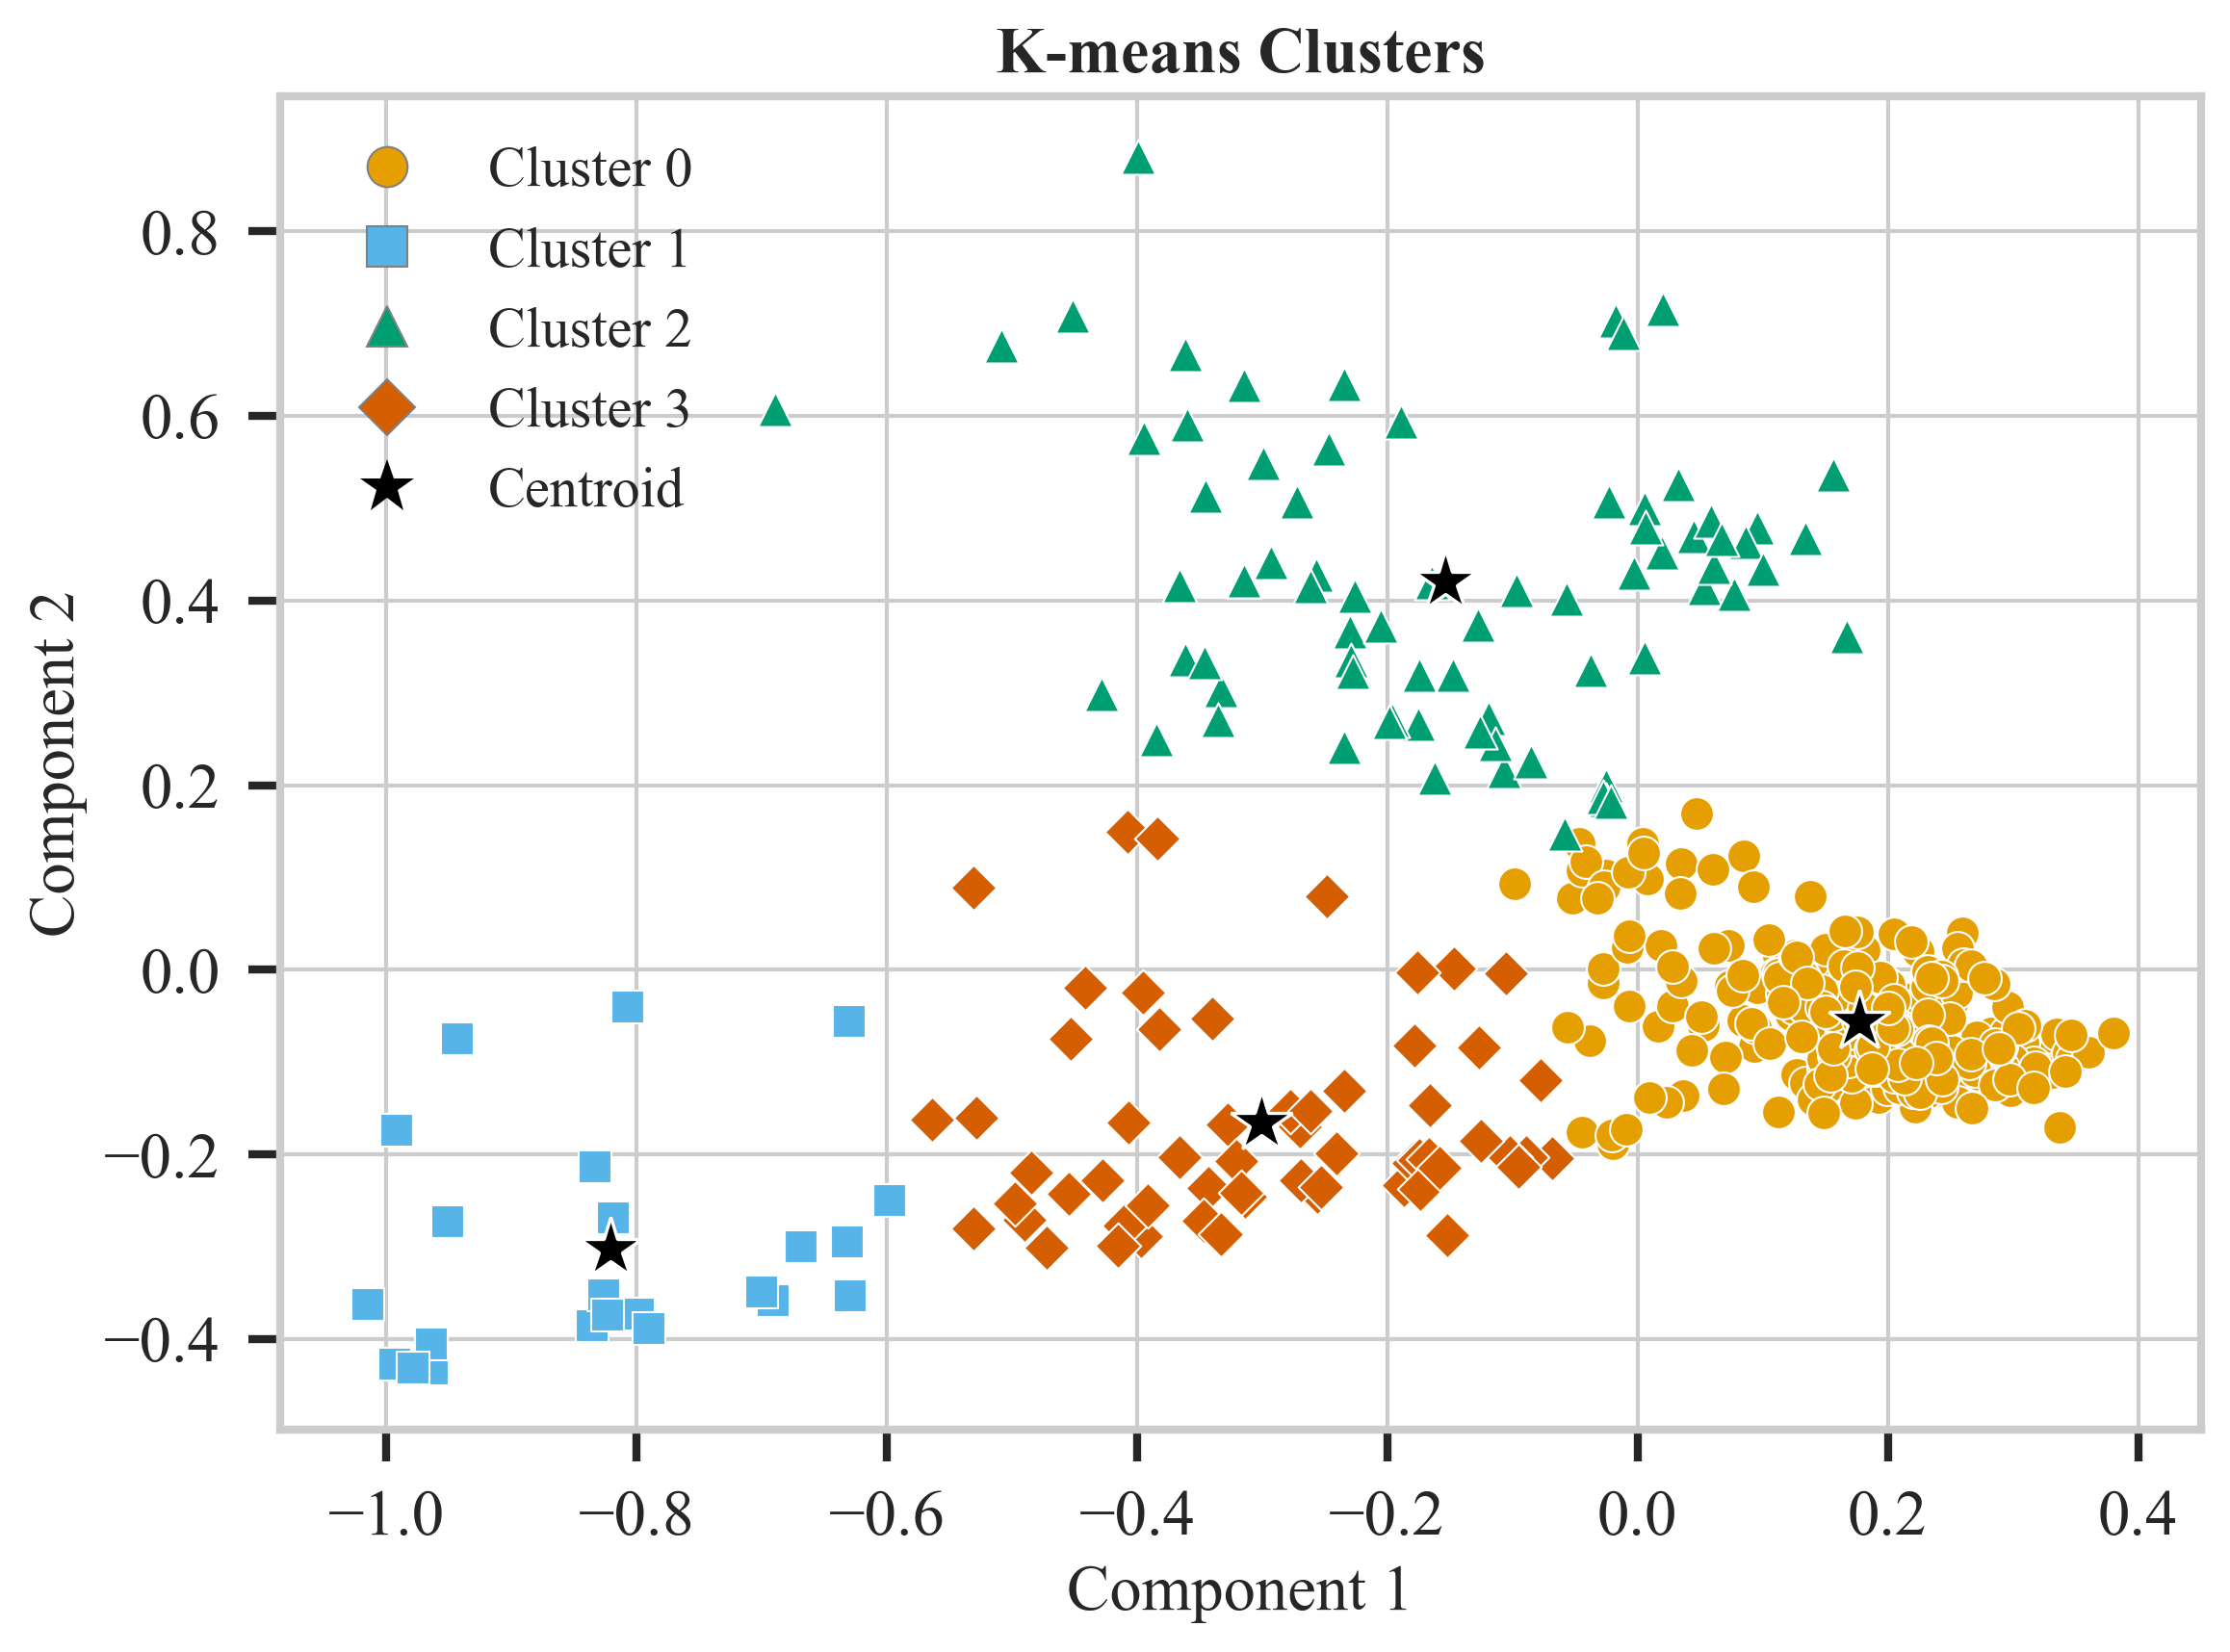

In [ ]:
# K-Means
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

color_theme = np.array(["#E69F00", "#56B4E9", "#009E73", "#D55E00"])
markers = ['o', 's', '^', 'D']  
marker_sizes = [70, 65, 75, 65]
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel("Component 1", fontsize=16)
ax.set_ylabel("Component 2", fontsize=16)
ax.tick_params(axis='both', labelsize=16)

for i, name in enumerate(cluster_names):
    mask = nombres_pca.cluster == i
    ax.scatter(
        x=nombres_pca.C1[mask],
        y=nombres_pca.C2[mask],
        c=color_theme[i],
        marker=markers[i],
        s=marker_sizes[i],
        alpha=1,
        edgecolors='white',
        linewidths=0.5,
        label=name
    )


for i in range(len(centroides)):
    ax.plot(
        centroides[i][0], centroides[i][1],
        marker='*', color='black',
        markersize=16, markeredgecolor='white',
        markeredgewidth=0.8,
        zorder=5
    )


handles = []
for i, name in enumerate(cluster_names):
    handle = mlines.Line2D(
        [], [],
        marker=markers[i],
        color='w',
        markerfacecolor=color_theme[i],
        markeredgecolor='grey',
        markeredgewidth=0.5,
        markersize=10,
        label=name
    )
    handles.append(handle)


centroid_handle = mlines.Line2D(
    [], [],
    marker='*', color='w',
    markerfacecolor='black',
    markersize=14,
    label='Centroid'
)
handles.append(centroid_handle)

ax.legend(handles=handles, loc='upper left', fontsize=14, framealpha=0.9)
plt.title('K-means Clusters', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig('K-means_Clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# DBSCAN and Gaussian Mixture Clustering Pipelines
p_cdb = Pipeline([
    ('DBSCAN', DBSCAN(eps=0.09, min_samples=4, metric='euclidean'))
])
p_cgm = Pipeline([
    ('gmm', GaussianMixture(n_components=4, random_state=42))
])
p_prep = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])
p_db = Pipeline([
    ('preprocessing', p_prep),
    ('clus_db', p_cdb)
])
p_gm = Pipeline([
    ('preprocessing', p_prep),
    ('clus_gm', p_cgm)
])
dbscan_labels = p_db.fit_predict(df5)
gmm_labels = p_gm.fit_predict(df5)

In [37]:
kmeans_labels = nombres_pca['cluster']

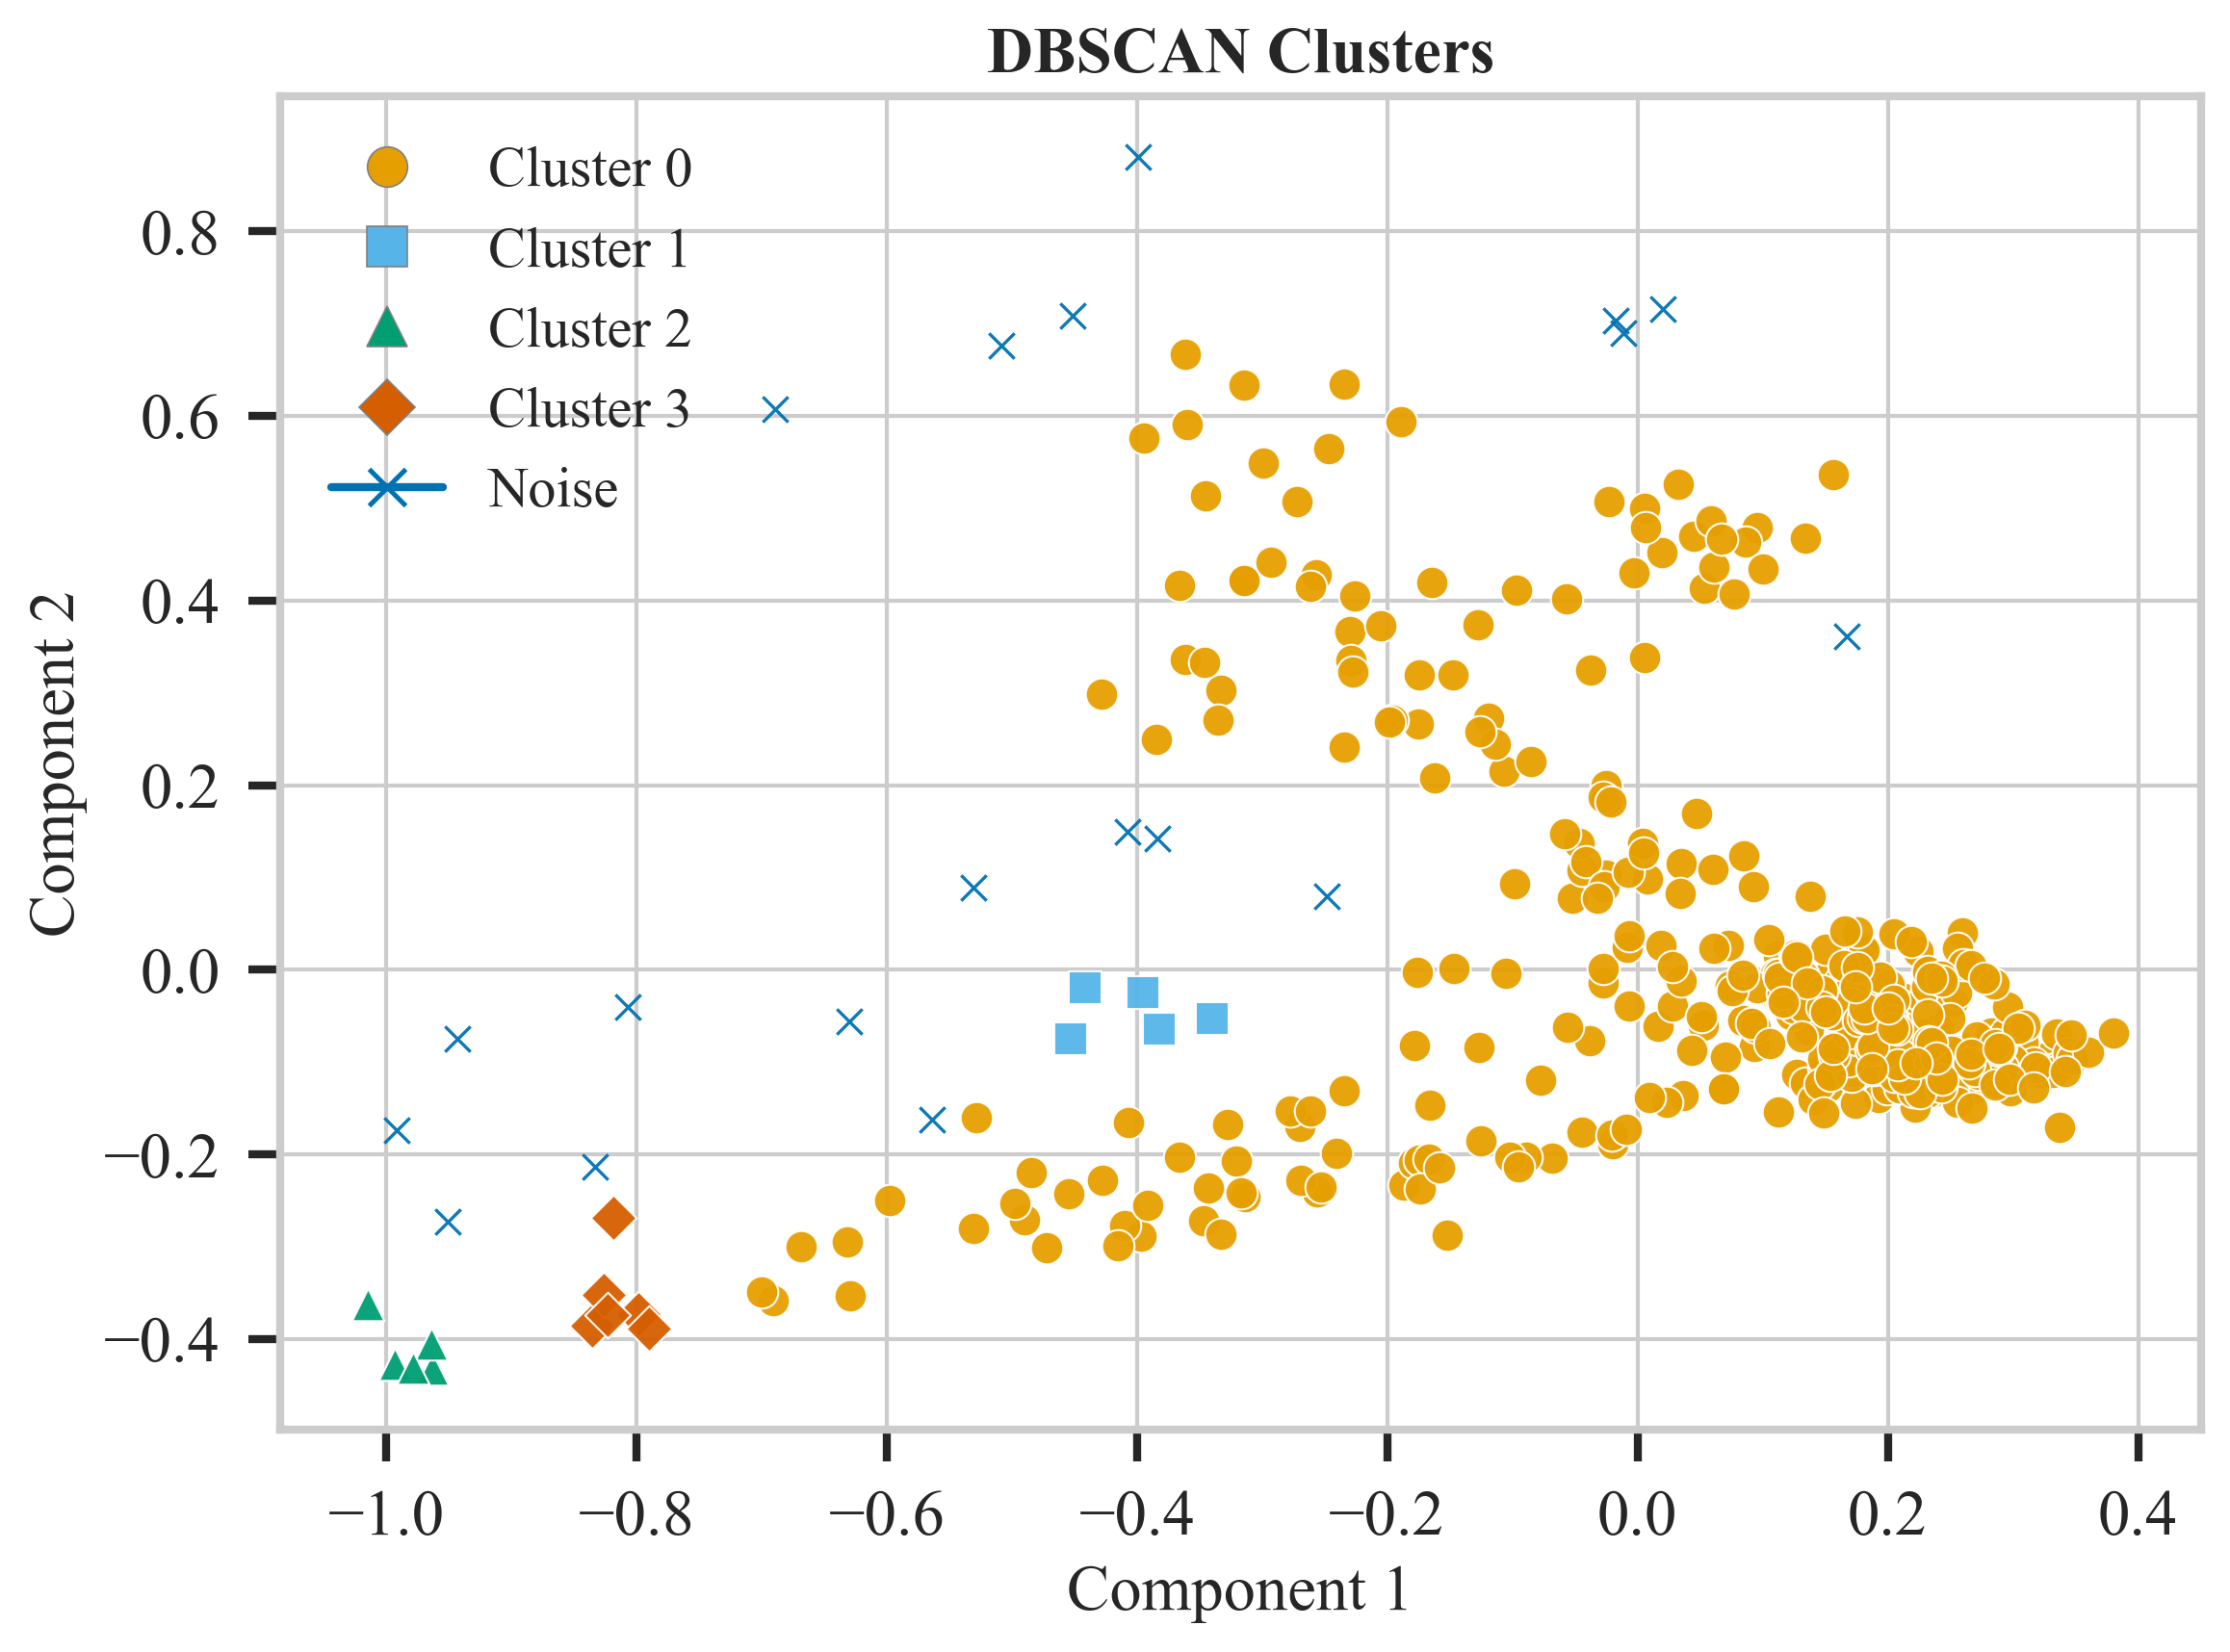

In [38]:
# DBSCAN Cluster Visualization
wong_colors = [
    '#E69F00', '#56B4E9', '#009E73', '#D55E00',
    '#0072B2', '#CC79A7', '#F0E442',
]
markers = ['o', 's', '^', 'D', 'P', 'X', 'v']

unique_clusters = np.unique(dbscan_labels)
valid_clusters = sorted([c for c in unique_clusters if c != -1])
has_noise = -1 in unique_clusters

fig, ax = plt.subplots(figsize=(8, 6))

if has_noise:
    noise_mask = dbscan_labels == -1
    ax.scatter(
        nombres_pca.C1[noise_mask],
        nombres_pca.C2[noise_mask],
        c='#0072B2',
        marker='x',
        s=40,
        alpha=0.95,
        linewidths=0.8,
        label='Noise',
        zorder=2
    )

for idx, cluster in enumerate(valid_clusters):
    mask = dbscan_labels == cluster
    color = wong_colors[idx % len(wong_colors)]
    marker = markers[idx % len(markers)]
    ax.scatter(
        nombres_pca.C1[mask],
        nombres_pca.C2[mask],
        c=color,
        marker=marker,
        s=65,
        alpha=0.95,
        edgecolors='white',
        linewidths=0.5,
        zorder=3
    )

handles = []
for idx, cluster in enumerate(valid_clusters):
    color = wong_colors[idx % len(wong_colors)]
    marker = markers[idx % len(markers)]
    handle = mlines.Line2D(
        [], [],
        marker=marker,
        color='w',
        markerfacecolor=color,
        markeredgecolor='grey',
        markeredgewidth=0.4,
        markersize=10,
        label=f'Cluster {cluster}'
    )
    handles.append(handle)

if has_noise:
    noise_handle = mlines.Line2D(
        [], [],
        marker='x',
        color='#0072B2',
        markersize=9,
        label='Noise',
        markeredgewidth=1.2
    )
    handles.append(noise_handle)

ax.legend(handles=handles, loc='upper left', fontsize=14, framealpha=0.9)
ax.set_xlabel('Component 1', fontsize=16)
ax.set_ylabel('Component 2', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.title('DBSCAN Clusters', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig('dbscan_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

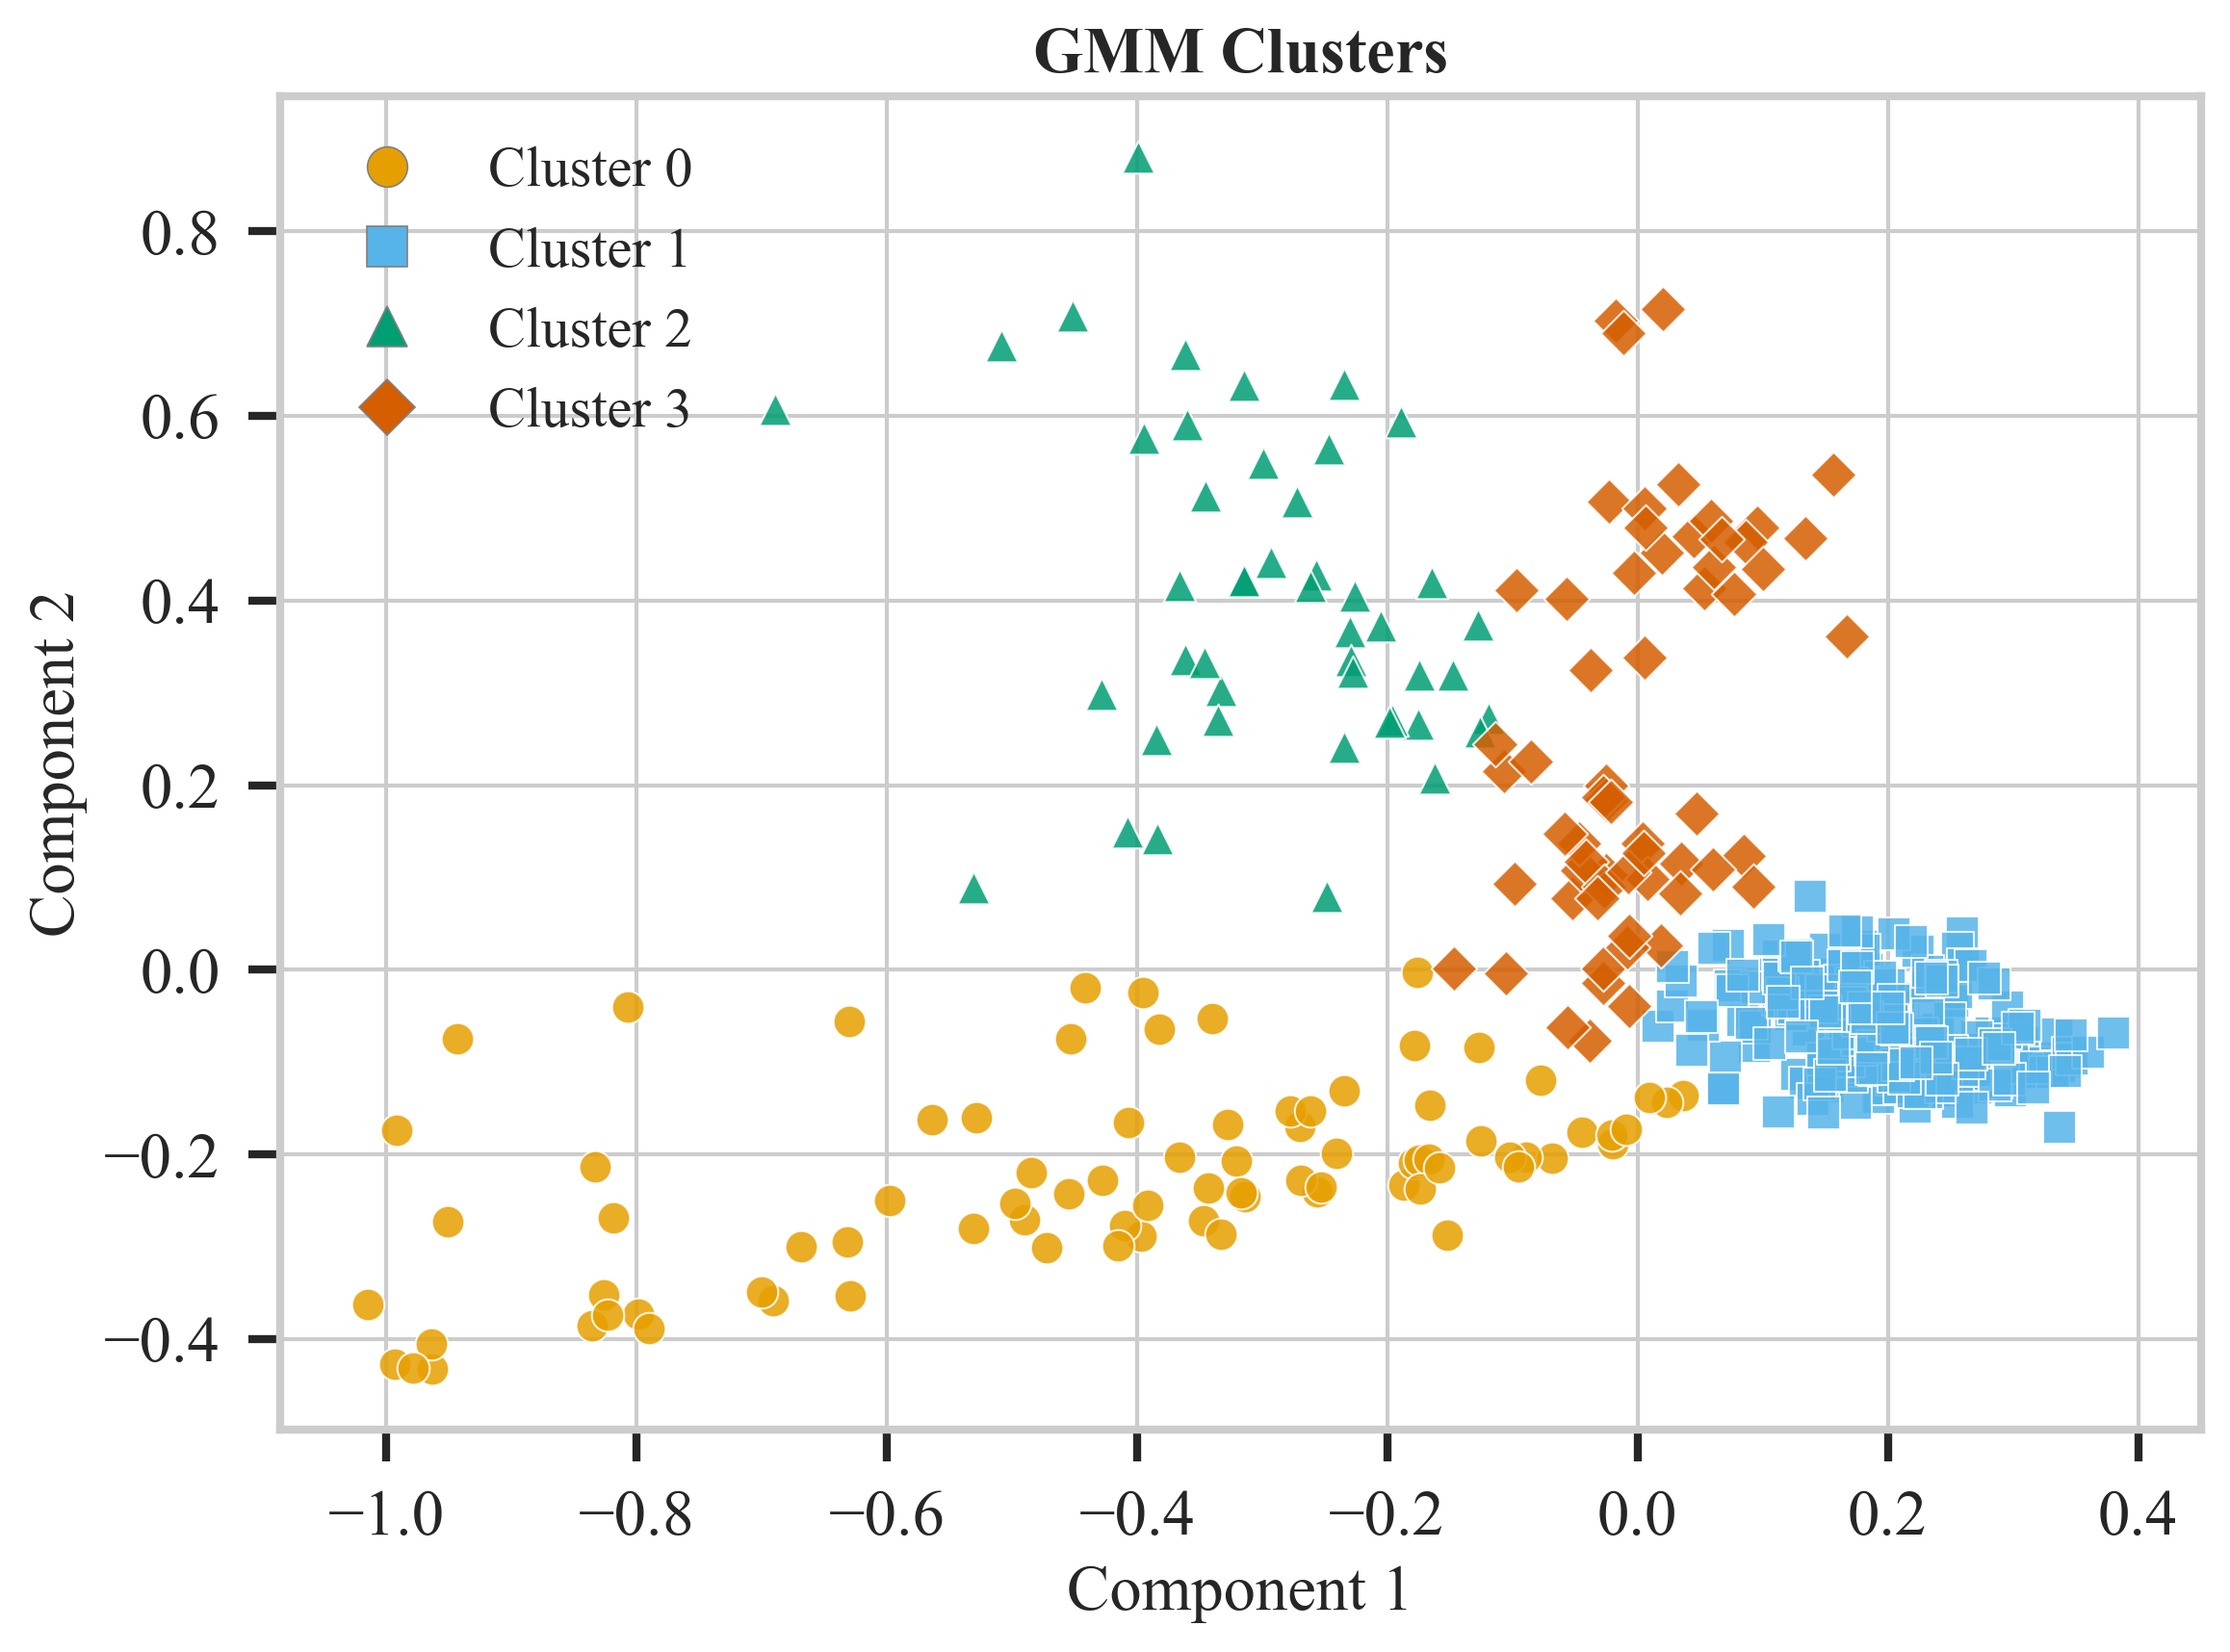

In [39]:
# GMM Cluster Visualization
wong_colors = [
    '#E69F00', '#56B4E9', '#009E73', '#D55E00',
    '#CC79A7', '#0072B2', '#F0E442',
]
markers = ['o', 's', '^', 'D', 'P', 'X', 'v']

unique_clusters = np.unique(gmm_labels)

fig, ax = plt.subplots(figsize=(8, 6))

for idx, cluster in enumerate(unique_clusters):
    mask = gmm_labels == cluster
    color = wong_colors[idx % len(wong_colors)]
    marker = markers[idx % len(markers)]
    ax.scatter(
        nombres_pca.C1[mask],
        nombres_pca.C2[mask],
        c=color, marker=marker, s=65, alpha=0.85,
        edgecolors='white', linewidths=0.5, zorder=3)

handles = []
for idx, cluster in enumerate(unique_clusters):
    handles.append(mlines.Line2D([], [],
        marker=markers[idx % len(markers)],
        color='w',
        markerfacecolor=wong_colors[idx % len(wong_colors)],
        markeredgecolor='grey', markeredgewidth=0.4,
        markersize=10, label=f'Cluster {cluster}'))

ax.legend(handles=handles, loc='upper left', fontsize=14, framealpha=0.9)
ax.set_xlabel('Component 1', fontsize=16)
ax.set_ylabel('Component 2', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.title('GMM Clusters', fontsize=16, fontweight='bold')
plt.tight_layout()
fig.savefig('gmm_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# Clustering Metrics: Davies-Bouldin and Silhouette Scores
def calculo_davies_bouldin(labels):
    return davies_bouldin_score(nombres_pca, labels)

In [41]:
davies_bouldin = calculo_davies_bouldin(kmeans_labels)
print(f"davies_bouldin of the K-means: {davies_bouldin:.4f}")

davies_bouldindbscan = calculo_davies_bouldin(dbscan_labels)
print(f"davies_bouldin of the DBSCAN: {davies_bouldindbscan:.4f}")

davies_bouldinGMM = calculo_davies_bouldin(gmm_labels)
print(f"davies_bouldin of the GMM: {davies_bouldinGMM:.4f}")

davies_bouldin of the K-means: 0.2716
davies_bouldin of the DBSCAN: 1.1414
davies_bouldin of the GMM: 1.7078


In [ ]:
def calculo_silhouette(df):
    silhouette = silhouette_score(nombres_pca,df)    
    return silhouette_score

In [43]:
silhouetteKmean = silhouette_score(nombres_pca, kmeans_labels )
silhouettedbscan = silhouette_score(nombres_pca, dbscan_labels)
silhouetteGMM = silhouette_score(nombres_pca, gmm_labels)
print(f"silhouette of the K-means: {silhouetteKmean:.4f}")
print(f"silhouette of the DBSCAN: {silhouettedbscan:.4f}")
print(f"silhouette of the GMM: {silhouetteGMM:.4f}")

silhouette of the K-means: 0.8595
silhouette of the DBSCAN: 0.0878
silhouette of the GMM: 0.4849


In [44]:
df6= pd.concat([df_limpiototal, pd.DataFrame(data = clustering.labels_, columns = ['cluster'])], axis = 1)

In [45]:
df6.to_csv('dfR_datosclusterp2C.csv', index=False)

In [46]:
# Cluster Averages and Counts
df_numeric = df6.select_dtypes(include=['number'])
averages = df_numeric.groupby('cluster').mean()
print(averages)

cluster_count = df6.groupby('cluster').size()
print(cluster_count)

         AR_Moisturecontent  AR_Ashcontent  AR_Volatilematter  AR_Fixedcarbon  \
cluster                                                                         
0                  9.390815       4.494741          70.905963       15.208370   
1                 69.038696       6.707826          19.317826        4.936087   
2                  5.841333      28.718133          37.450533       27.589600   
3                 37.652931       5.910345          45.981552       10.455517   

         AR_Netcalorificvalue(LHV)  AR_Carbon  AR_Hydrogen  AR_Nitrogen  \
cluster                                                                   
0                        15.911556  43.457963     5.369148     0.631815   
1                         2.879130  11.980870     1.559130     0.426087   
2                        17.033067  44.185333     3.765867     2.010133   
3                         9.792931  28.474310     3.453448     0.534138   

         AR_Sulphur  AR_Oxygen  
cluster                      

In [47]:
def calculate_variances(df, cluster_column='cluster'):
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != cluster_column]
    data = df[numeric_cols]
    clusters = df[cluster_column]

    total_variance = data.var(ddof=1).sum()
    global_mean = data.mean()

    cluster_stats, intra_variance, inter_variance = {}, 0, 0
    for cluster_id in clusters.unique():
        cluster_data = data[clusters == cluster_id]
        size = len(cluster_data)
        var = cluster_data.var(ddof=1).sum()
        mean = cluster_data.mean()

        intra_variance += var * size
        inter_variance += ((mean - global_mean) ** 2).sum() * size
        cluster_stats[f'Cluster_{cluster_id}'] = {'size': size, 'variance': var, 'mean': mean.to_dict()}

    intra_variance /= len(df)
    inter_variance /= len(df)
    calculated_total = inter_variance + intra_variance
    variance_ratio = inter_variance / total_variance if total_variance > 0 else 0

    return {
        'total_variance': total_variance,
        'inter_cluster_variance': inter_variance,
        'intra_cluster_variance': intra_variance,
        'calculated_total_variance': calculated_total,
        'verification_difference': abs(total_variance - calculated_total),
        'explained_variance_ratio': variance_ratio,
        'cluster_statistics': cluster_stats,
        'number_of_clusters': len(clusters.unique()),
        'number_of_observations': len(df),
        'analyzed_variables': numeric_cols,
    }


def print_variance_report(results):
    r = results
    print("=" * 60)
    print("CLUSTER VARIANCE ANALYSIS REPORT")
    print("=" * 60)
    print(f"\nGENERAL SUMMARY:")
    print(f"   Number of clusters: {r['number_of_clusters']}")
    print(f"   Number of observations: {r['number_of_observations']}")
    print(f"   Variables analyzed: {len(r['analyzed_variables'])}")
    print(f"   Variables: {', '.join(r['analyzed_variables'])}")
    print(f"\nVARIANCES:")
    print(f"   Total Variance:       {r['total_variance']:.4f}")
    print(f"   Inter-cluster Variance: {r['inter_cluster_variance']:.4f}")
    print(f"   Intra-cluster Variance: {r['intra_cluster_variance']:.4f}")
    print(f"\nVERIFICATION:")
    print(f"   Inter + Intra = {r['calculated_total_variance']:.4f}")
    print(f"   Difference: {r['verification_difference']:.6f}")
    print(f"\nCLUSTERING QUALITY:")
    print(f"   Explained variance ratio: {r['explained_variance_ratio']:.4f} ({r['explained_variance_ratio']*100:.2f}%)")

    quality = (
        "Excellent" if r['explained_variance_ratio'] > 0.7 else
        "Good" if r['explained_variance_ratio'] > 0.5 else
        "Moderate" if r['explained_variance_ratio'] > 0.3 else
        "Poor"
    )
    print(f"   {quality} separation between clusters")

    print(f"\nSTATISTICS BY CLUSTER:")
    for name, stats in r['cluster_statistics'].items():
        print(f"   {name}:")
        print(f"     Size: {stats['size']} observations")
        print(f"     Variance: {stats['variance']:.4f}")

In [48]:
results = calculate_variances(nombres_pca, 'cluster')
print_variance_report(results)

CLUSTER VARIANCE ANALYSIS REPORT

GENERAL SUMMARY:
   Number of clusters: 4
   Number of observations: 426
   Variables analyzed: 2
   Variables: C1, C2

VARIANCES:
   Total Variance:       0.1393
   Inter-cluster Variance: 0.1144
   Intra-cluster Variance: 0.0249

VERIFICATION:
   Inter + Intra = 0.1393
   Difference: 0.000012

CLUSTERING QUALITY:
   Explained variance ratio: 0.8214 (82.14%)
   Excellent separation between clusters

STATISTICS BY CLUSTER:
   Cluster_0:
     Size: 270 observations
     Variance: 0.0142
   Cluster_3:
     Size: 58 observations
     Variance: 0.0315
   Cluster_2:
     Size: 75 observations
     Variance: 0.0556
   Cluster_1:
     Size: 23 observations
     Variance: 0.0326
